# Objectif du notebook 

Calcul des RTFs pour la séquence de remontée verticale numéro : 95

Date de création : 18/08/2026

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
print(project_root)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

c:\Users\baptiste.menetrier\Desktop\devPy\phd


In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

# Définition des paramètres du processeur pour l'estimation des RTFs

In [4]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response

fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study
    "tau_rtf_analysis": 2,
    "alpha_overlap": 0.75,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

# Données communes 


In [5]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load bathy data
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Load wav data
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

In [6]:
def print_sequence_info(df_seq):
    print("\n")
    print(f"Processing sequence {df_seq['sequence_id'].iloc[0]} with following properties:")
    print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
    print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
    print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
    print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
    print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
    print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")
    print(f"\tSource depth: {df_seq['deployed_length_m'].iloc[0]} meters")

In [7]:
def run_rtf_estimation(seq_id):
    # Convention for the global dataset -> seq_id + 1000
    id_event = 1000 + seq_id

    target_mmsi = None
    active_feature_args = {
        "replica_sequence_ids": [seq_id],
        "replica_pulse_slice": [(0, 20)],
        "load_precomputed_feature": False,
    }
    passive_feature_args = {
        "start_datetimes": [],
        "end_datetimes": [],
        "load_precomputed_feature": False,
    }

    rtf_mfp_processor.compute_event(
        active_feature_args=active_feature_args,
        passive_feature_args=passive_feature_args,
        id=id_event,
        target_mmsi=target_mmsi,
    )

In [8]:
def plot_source_depth(df_seq):
    fpath_rbr = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\RBR\207416_20251016_1535_data.csv"
    df_rbr = pd.read_csv(fpath_rbr, header=0, delimiter=",")
    # dt_fmt = df_rbr.columns[0].replace("T", " ")
    df_rbr["datetime"] = pd.to_datetime(df_rbr[df_rbr.columns[0]])  # Format is explicit

    # Slice the required sequence
    df_rbr_seq = df_rbr.loc[
        df_rbr["datetime"].between(
            df_seq["emission_datetime"].min(), df_seq["emission_datetime"].max()
        )
    ]

    # Plot depth variations along the sequence
    plt.figure()
    plt.plot(df_rbr_seq["datetime"], df_rbr_seq["Depth [m]"], marker="o")
    plt.xlabel("Datetime")
    plt.ylabel("Source depth [m]")
    
    print("\n")
    print(f"Source depth variations during sequence {df_seq['sequence_id'].iloc[0]}:")
    print(f"\tMinimum depth: {df_rbr_seq['Depth [m]'].min():.2f} m")
    print(f"\tMaximum depth: {df_rbr_seq['Depth [m]'].max():.2f} m")
    print(f"\tMedian depth: {df_rbr_seq['Depth [m]'].median():.2f} m")

In [9]:
def analyse_dr_variation(ds):
    # OBS position
    e1 = ds_gps.attrs[f"obs1_e_apriori"]
    n1 = ds_gps.attrs[f"obs1_n_apriori"]
    e2 = ds_gps.attrs[f"obs2_e_apriori"]
    n2 = ds_gps.attrs[f"obs2_n_apriori"]
    e3 = ds_gps.attrs[f"obs3_e_apriori"]
    n3 = ds_gps.attrs[f"obs3_n_apriori"]

    # Source positions
    es = ds.e_replica
    ns = ds.n_replica

    # Distance
    r1 = np.sqrt((e1 - es) ** 2 + (n1 - ns) ** 2).values
    r2 = np.sqrt((e2 - es) ** 2 + (n2 - ns) ** 2).values
    r3 = np.sqrt((e3 - es) ** 2 + (n3 - ns) ** 2).values

    dr = np.abs(r1[1:] - r1[:-1])
    dr_med = np.median(np.abs(dr))
    dr_mean = np.mean(np.abs(dr))
    dr_std = np.std(np.abs(dr))
    
    print("\n")
    print("Range resolution :")
    print(f"\t median delta_r = {dr_med:.1f}m")
    print(f"\t mean delta_r = {dr_mean:.1f}m")
    print(f"\t std delta_r = {dr_std:.1f}m")

    print(f"r1 min: {r1.min()}, r1 max: {r1.max()}")
    print(f"r2 min: {r2.min()}, r2 max: {r2.max()}")
    print(f"r3 min: {r2.min()}, r3 max: {r3.max()}")

    plt.figure()
    plt.plot(ds.replica_id.values[1:], dr)
    plt.axhline(dr_med, color="k", linestyle="--")
    plt.xlabel("Replica ID")
    plt.ylabel("$\Delta r$ [m]")

In [10]:
root_event = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\event"
root_active = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active"

def run_all_seq_analysis(seq_id, run_estimation=False):

    # Load entire sequence
    df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]
    # Print usefull info
    print_sequence_info(df_seq)

    # Run estimation if needed
    if run_estimation:
        run_rtf_estimation(seq_id)

    # Load RTF dataset
    id_event = 1000 + seq_id  # Convention for the global dataset -> seq_id + 1000
    fpath = os.path.join(root_event, f"event_{id_event}.nc")
    try:
        ds = xr.open_dataset(fpath)
    except:
        print(f"Dataset {fpath} not found !")

    # Plot replicas positions
    plot_seq_replica_positions(df_seq, ds_gps)
    plot_seq_replica_positions_wgs84(df_seq, ds_gps, ds_bathy, add_transect_points=True)

    # Plot speed of the source
    plot_speed_along_seq(df_seq)

    # Plot source depth
    plot_source_depth(df_seq)

    # Analyse range resolution 
    analyse_dr_variation(ds)

    # Plot signal spectrograms
    fpath = os.path.join(root_active, f"sequence_{seq_id}_rtf.nc")
    try:
        ds_sig = xr.open_dataset(fpath)
        ds_sig
    except:
        print(f"Dataset {fpath} not found !")

    plot_sequence_spectrogram(
        ds_sig,
        ds_wav,
        nperseg=2**12,
        noverlap=2**11,
        # fmin=fmin,
        # fmax=fmax,
        # fname="sequence_signal_spectrogram.png",
    )

    # Plot RTF
    dist_rcv = get_dist_to_rcv(ds)
    obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
    reps = ds.replica_id.values

    plot_gamma_along_sequence(
        ds,
        dist_rcv,
        obs_cpa_idx,
        reps,
        # fmin=fmin,
        # fmax=fmax,
    )

    return ds

# Séquence 91

In [11]:
# ds = run_all_seq_analysis(seq_id=91, run_estimation=False)

In [12]:
# 20 * np.log10(ds.rtf_amp).sel(h_index=3).plot(x="f_rtf", hue="replica_id")

NameError: name 'ds' is not defined

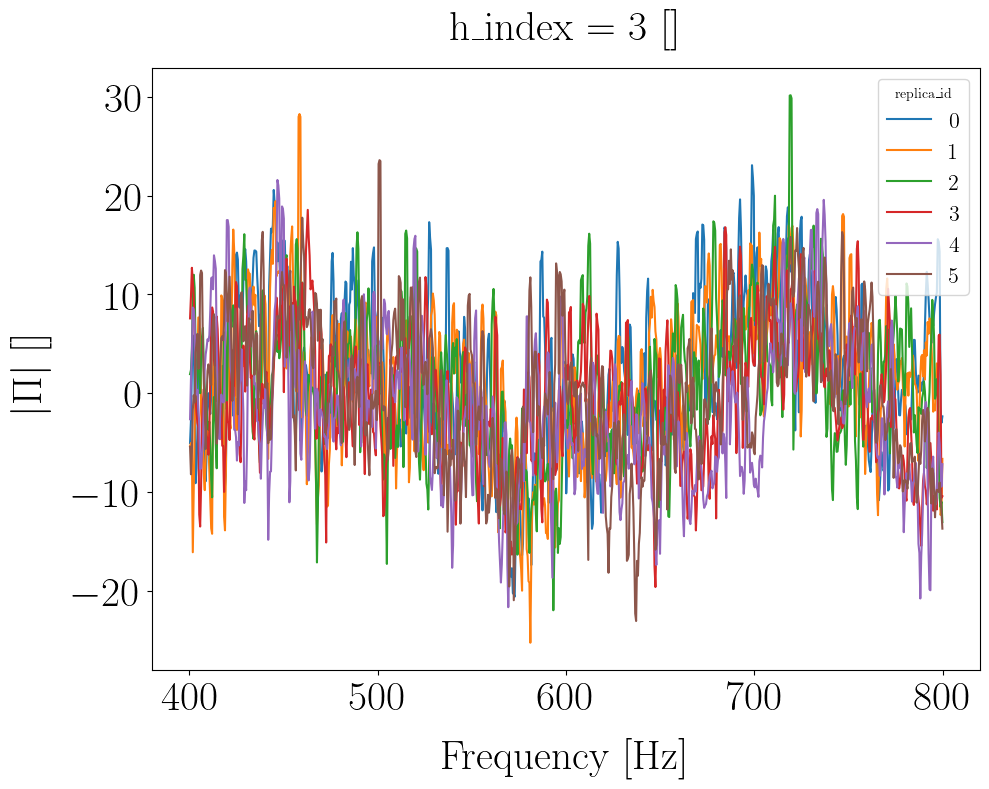

In [ ]:
# pi_roll = 20 * np.log10(ds.rtf_amp.rolling(f_rtf=3, center=True).mean())

# pi_roll.sel(h_index=3).sel(f_rtf=slice(400, 800)).sel(replica_id=slice(0, 5)).plot(x="f_rtf", hue="replica_id")

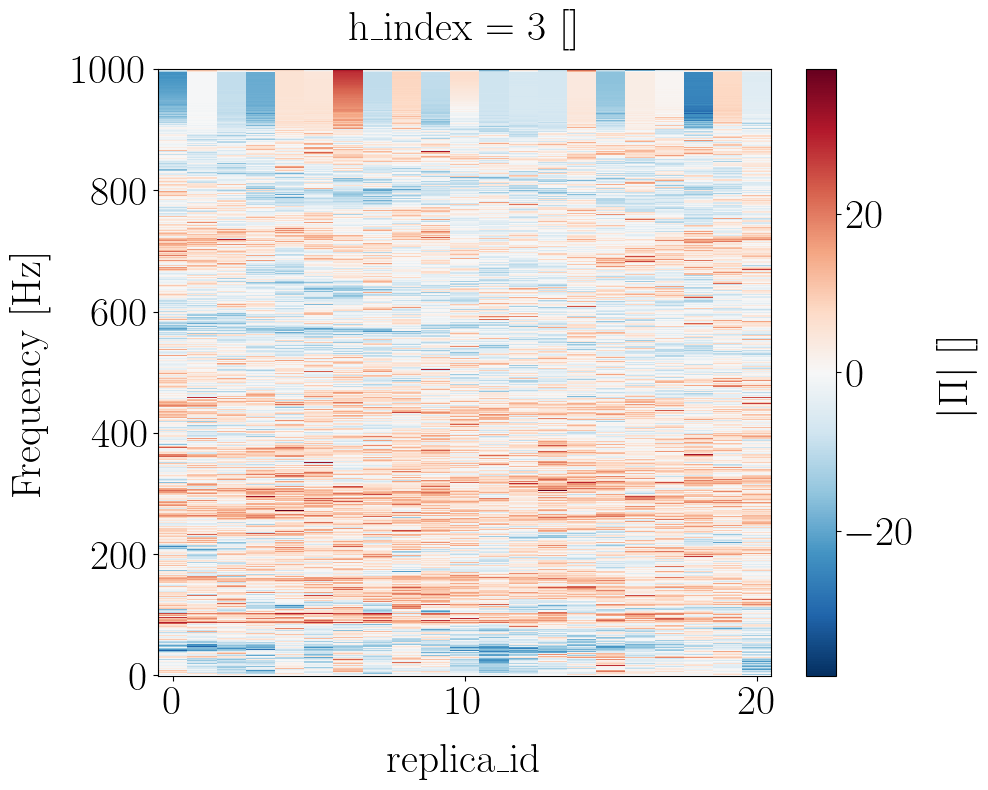

In [ ]:
# pi_roll.sel(h_index=3).plot()

# Séquence 71

Pulses non détectés : séquence non exploitable.  

In [ ]:
# ds = run_all_seq_analysis(seq_id=71, run_estimation=True)

# Séquence 168


In [16]:
ds = run_all_seq_analysis(seq_id=168, run_estimation=True)



Processing sequence 168 with following properties:
	Number of pulses: 24
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 1.0 seconds
	Repeat period: 2.0 seconds
	Source depth: 8 meters

Deriving features for active source...

RTF processing of sequences [] (nb of sequences = 0)

Deriving replicas for passive source...
Replica file for sequence 168 not found at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_168_rtf.nc.


UnboundLocalError: cannot access local variable 'rtf_amp' where it is not associated with a value

In [ ]:
20 * np.log10(ds.rtf_amp).sel(h_index=3).plot(x="f_rtf", hue="replica_id")

NameError: name 'ds' is not defined

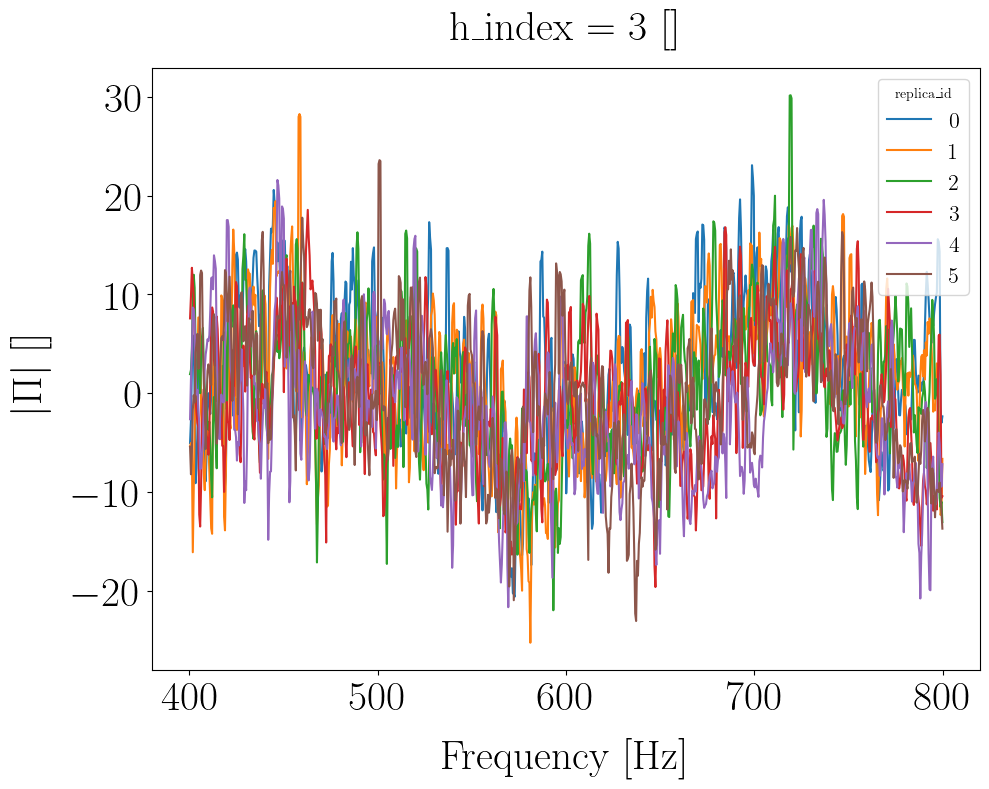

In [ ]:
pi_roll = 20 * np.log10(ds.rtf_amp.rolling(f_rtf=3, center=True).mean())

pi_roll.sel(h_index=3).sel(f_rtf=slice(400, 800)).sel(replica_id=slice(0, 5)).plot(x="f_rtf", hue="replica_id")